# Logistic Regression, Sigmoid Function, and Gradient Descent

## Overview

This notebook is used for personal learning of Logistic Regression and its workigns with Gradient descent, and as such is implemented using only numpy in order to understand the inner workings.



## Logistic Regression and Sigmoid Function

Logistic Regression is a supervised machine learning classification algorithm. It works by outputting a probability value:

<h5 style="text-align: center;">0 ≤ P(σ) ≤ 1</h5>


The expected predicted value is always a range of 0 to 1 stating the probability of it being true where, where 0 is 0% and 1 is 100%.

Logistic Regression in its essence is a Sigmoid Function where the input value passed to it is Linear Regression.

When you are faced with a classification problem, you want to answer a simple question: **"What is the chance (probability) that this item belongs to a specific category?"**

To understand why we combine Linear Regression and the Sigmoid function, let's look at how they work together conceptually:

*   **The Problem with Linear Regression:** A standard linear model calculates a score for your data. The issue is that this score can be anything—from very large negative numbers to very large positive numbers (like `-520` or `10,432`). These numbers do not make sense as probabilities because a probability must always be between `0` and `1`.
*   **The Sigmoid Solution:** The Sigmoid function acts like a converter of sort which in a way `squashes` those values. It takes that infinite score range from the linear model and maps it onto a strict scale between `0` and `1`.

### The Simple Logic:
1.  **High Positive Score** $\rightarrow$ Sigmoid squashes it close to **1** $\rightarrow$ **High Probability** (e.g., 99% chance)
2.  **Score of Exactly Zero** $\rightarrow$ Sigmoid places it at exactly **0.5** $\rightarrow$ **50/50 Coin Flip**
3.  **High Negative Score** $\rightarrow$ Sigmoid squashes it close to **0** $\rightarrow$ **Low Probability** (e.g., 1% chance)

By passing the linear regression score into the sigmoid function, we successfully turn a raw, unbounded number into a clean, usable percentage.

### Labels


1. **Input Data** ($x$)
2. **Linear Score** ($f_{w,b}(x)$) $\rightarrow$ *Can be any number from negative to positive infinity*
3. **Sigmoid Transformation** ($\sigma$) $\rightarrow$ *Acts as the squashing function*
4. **Probability Output** ($y$) $\rightarrow$ *The final percentage strictly between 0 and 1*

In short: **Output Probability** is the result of passing the **Linear Score** through the **Sigmoid Filter**.


<h2 style="text-align: center;">Linear Regression Formula</h2>

The linear score is calculated as the weighted sum of features plus a bias term aka Linear Regression, for multiple features you would have multiple weighted sums:

$$z = f_{w,b}(x) = w \cdot x + b$$

Where:
* $w$ represents the weights (parameters)
* $x$ represents the input features
* $b$ represents the bias (intercept)

---

<h2 style="text-align: center;">Sigmoid Function Formula</h2>

The function that maps any real-valued number into a strict range between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where:
* $z$ is the input score from the linear model
* $e$ is Euler's number (~2.71828)

---

<h2 style="text-align: center;">Logistic Regression Formula</h2>

By substituting the linear regression formula ($z$) directly into the sigmoid function, we get the final predictive model:

$$y = \sigma(f_{w,b}(x)) = \frac{1}{1 + e^{-(w \cdot x + b)}}$$

Where:
* $y$ is the final predicted probability ($0 \le y \le 1$) that the input belongs to class 1.


## 1. Example with predicted w and b for showcase

In [288]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Paramaters already predicted: w = 2.0, b = -6.0
X = np.array([[1.0], [1.5], [2.0], [2.5], [3.5], [4.0], [4.5], [5.0]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])


In [289]:
"""
Sigmoid Function Implemented

- def Sigmoid returns predicted value
- z is the Linear Regression value passed to the sigmoid function
"""

def LogisticRegression(X,w,b):
    
    z = LinearRegression(X,w,b)
    
    # Sigmoid Function
    denominator = 1 + np.exp(-z)
    y_predicted = 1 / denominator
    
    return y_predicted

def LinearRegression(X,w,b):
    
    # z = w * x + b
    z = np.dot(X, w) + b
    return z
    


# Test data
X_test = np.array([[0.9], [1.4], [2.2], [2.4], [3.2], [3.9], [4.3], [4.5], [3.0]])
w_true = np.array([2.0])
b_true = -6.0
probabilities = LogisticRegression(X_test, w_true, b_true)



print("X train values: ", X.flatten())
print("Y train values: ", y)
print("X_test:", X_test.flatten())
print("Пресметани веројатности:", np.round(probabilities, 4))

X train values:  [1.  1.5 2.  2.5 3.5 4.  4.5 5. ]
Y train values:  [0 0 0 0 1 1 1 1]
X_test: [0.9 1.4 2.2 2.4 3.2 3.9 4.3 4.5 3. ]
Пресметани веројатности: [0.0148 0.0392 0.168  0.2315 0.5987 0.8581 0.9309 0.9526 0.5   ]


<h2 style="text-align: center;">The Predictable NumPy Dataset</h2>

To test our code and easily plot graphs, we created a 1D dataset where the classification line is obvious:
* Inputs below `3.0` belong to **Class 0**.
* Inputs above `3.0` belong to **Class 1**.

Because the threshold is exactly at `3.0`, we can perfectly predict our optimal parameters to be **$w = 2.0$** and **$b = -6.0$**. 

Beacuse,
When $x = 3.0$:
$$z = (2.0 \times 3.0) + (-6.0) = 0$$
And passing $0$ to the sigmoid function ($\sigma(0)$) yields exactly **0.5**—the perfect tipping point between our classes.

`The value where z = 0 is also called the decision boundary`


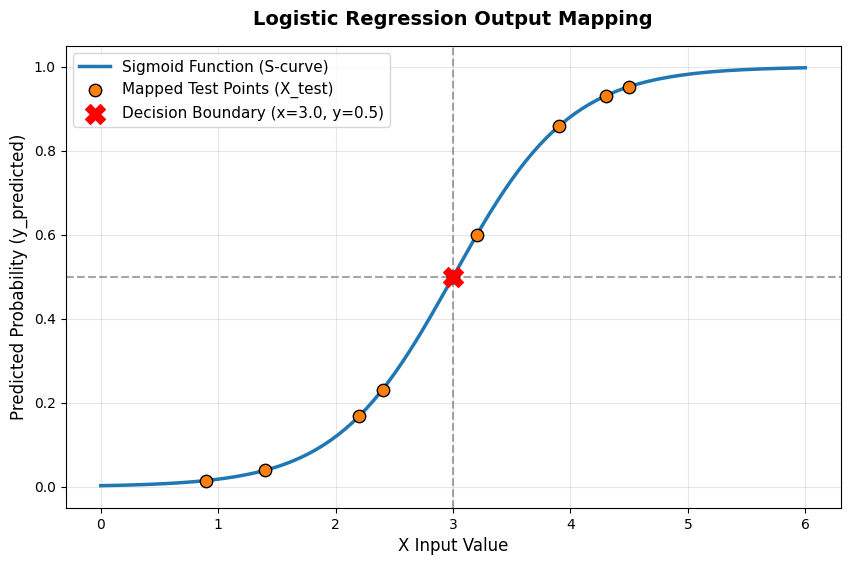

In [290]:
X_smooth = np.linspace(0, 6, 200).reshape(-1, 1)
z_smooth = LinearRegression(X_smooth, w_true, b_true)
y_smooth = 1 / (1 + np.exp(-z_smooth))

plt.figure(figsize=(10, 6))

# 1. Sigmoid plot
plt.plot(X_smooth, y_smooth, label='Sigmoid Function (S-curve)', color='#1f77b4', linewidth=2.5)

# 2. (X_test) 
plt.scatter(X_test, probabilities, color='#ff7f0e', zorder=5, s=80, edgecolors='k', 
            label='Mapped Test Points (X_test)')

# (Decision Boundary каде z=0, x=3.0, y=0.5)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
plt.axvline(3.0, color='gray', linestyle='--', alpha=0.7)
plt.scatter([3.0], [0.5], color='red', marker='X', s=200, zorder=6, 
            label='Decision Boundary (x=3.0, y=0.5)')


plt.title('Logistic Regression Output Mapping', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('X Input Value', fontsize=12)
plt.ylabel('Predicted Probability (y_predicted)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)

plt.show()


<h2 style="text-align: center;">Visualizing the Probability Mapping</h2>

Looking at the generated graph, we can visually confirm exactly how the Logistic Regression model and the decision boundary operate:

*   **The Blue Line (S-Curve):** This is our Sigmoid filter. Notice how it smoothly transitions from `0` to `1`, never crossing those boundaries.
*   **The Orange Dots:** These are your exact `X_test` points mapped onto the curve. 
    *   Points like `0.9` and `1.4` have strong negative $z$ scores, placing them near `0`.
    *   Points like `3.9` and `4.5` have strong positive $z$ scores, pulling them near `1`.
*   **The Red 'X' (Decision Boundary):** Right at $x = 3.0$, our linear equation outputs $z = 0$. The Sigmoid of 0 is exactly `0.5`. Anything even slightly to the right of this threshold gets classified as **Class 1**, and anything to the left as **Class 0**.


<h2 style="text-align: center;">Cost function for Logistic Regression</h2>

In logistic regression, the cost is not calculated using the distance to a line (like Mean Squared Error). Using that method would create a non-convex function with many local minimums, making optimization too difficult.

<p style="text-align: center"> Linear Regression Cost Function </p>

$$
\begin{align}
    J_{w,b} = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{5}\\
\end{align}
$$

<div style="text-align: center;">
<img src="../graphs/output.png">
</div>

Which leads to the gradient descent giving us a non-convex function that could look like this:

<div style="text-align: center;">
<img src="../images/non-convex.png">
</div>



<h2 style="text-align: center;">Logistic Regression Loss Function (Log Loss)</h2>

The loss function evaluates how well our predicted probabilities match the actual binary targets. It is defined as a conditional piece-wise system for a single training example, and then averaged over the entire dataset.

### 1. Loss for a Single Training Example
For a single data point with true label $y$ and predicted probability $\hat{y}$ (where $\hat{y} = \sigma(z)$), the loss $L$ is calculated using this system:

$$
L(y, \hat{y}) = 
\begin{cases} 
-\log(\hat{y}) & \text{if } y = 1 \\ 
-\log(1 - \hat{y}) & \text{if } y = 0 
\end{cases}
$$

$$L(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$$

### 3. The Total Cost Function (J)
To find the total error across the entire dataset of $m$ training samples, we compute the average of all individual losses. We use an elegant solution for picking the appropriate logarithm part based on wether the predicted value is correct or incorrect. The elegant solution is using a cancelling out system, for this imagine that the Cost function is made up of two smaller equations.

1. One Equation if predicted value is the same actual desired test value: $log(\hat{y}^{(i)})$
2. And the other equation part if the values are different aka if it predicted wrong: $log(1 - \hat{y}^{(i)})$

If y=1 then:
$$(1 - y^{(i)}) = 0$$

Which cancels out the  part that calculates the actual error difference: $0=(1 - 1) \log(1 - \hat{y}^{(i)})$
So youre left with the: $log(\hat{y}^{(i)})$

and if y=0 then what cancels out is the first part beacuse of multiplying $0\log(\hat{y}^{(i)})$ which is 0 so youre left with : $log(1 - \hat{y}^{(i)})$

<h3 style="text-align: center;">Logistic Regression Loss Function (Log Loss)</h2>

$$J(f_{\mathbf{w},b}(x)) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Where:
* $m$ is the total number of data points (samples).
* $y^{(i)}$ is the actual true label ($0$ or $1$) of the $i$-th sample.
* $\hat{y}^{(i)}$ is the model's predicted probability for the $i$-th sample.



<div style="text-align: center;">
<img src="../images/logloss.jpg">
</div>

In [291]:
import pandas as pd

"""
    IMPORTANT:
    For this dataset true values are: P(pass) = sigmoid(1.2·hours - 7.2)
    
    w=1.2
    b=-7.2
"""



df = pd.read_csv('../data/logistic_1d.csv')

x = df['hours_studied']
y = df['passed']

df.head()


,hours_studied,passed
0,0.0,0
1,0.1,0
2,0.1,0
3,0.3,0
4,0.4,0


In [292]:
from sklearn.model_selection import train_test_split

# split into train/test datasets
X_train, X_test, y_train, y_test = train_test_split(x,y,
                                   test_size=0.20, 
                                   random_state=101,
                                   shuffle=True)

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

x = x.to_numpy()
y = y.to_numpy()

print('X_train : ')
print(X_train.size)
print('')
print('X_test : ')
print(X_test.size)
print('')
print('y_train : ')
print(y_train.size)
print('')
print('y_test : ')
print(y_test.size)


X_train : 
80

X_test : 
20

y_train : 
80

y_test : 
20


In [293]:
import numpy as np

def cost_function_logistic(x, y, w, b):
    # 1. Calculate predictions from Sigmoid (X @ w + b поминато низ сигмоид)
    p = LogisticRegression(x, w, b)
    
    # 2. IMPORTANT: This makes sure that the value is bitween 1e-15 and 1-e-15
    epsilon = 1e-15
    p = np.clip(p, epsilon, 1 - epsilon)
    
    # Vectorized Log Loss calculation
    errors_log = y * np.log(p) + (1 - y) * np.log(1 - p)
    
    # Logistic cost is the mean of all errors
    cost = -np.mean(errors_log)
    
    return cost


print(cost_function_logistic(x, y, 1.2, -7.2))


# McFarren Pseudo R^2 - Asks: How far from clueless am i? 
# where 0.693 is baseline learned nothing
print(1-(0.28190541115689516/0.693))
print(1-(0.3135820016237182/0.693))

0.28190541115689516
0.5932100849106852
0.5475007191576937


In [ ]:
def compute_derivative(x, y, w, b):
    
    m = x.shape[0]
    
    logistic_function = LogisticRegression(x, w, b) # sigmoid
    error = logistic_function - y # actual error for derivative
    
    d_dw = (1/m) * np.sum(error * x) # derivative compute for w
    d_db = (1/m) * np.sum(error) # derivative compute for b
    
    return d_dw, d_db


def gradient_descent(x, y, w, b, alpha, iterations):
    for i in range(iterations):
        d_dw, d_db = compute_derivative(x, y, w, b)
        
        w = w - alpha * d_dw
        b = b - alpha * d_db
        
        if i % 100 == 0:
            cost = cost_function_logistic(x, y, w, b)
            print(f"Iteration {i}: Cost = {cost:.4f}, w = {w:.4f}, b = {b:.4f}")
    
    return w, b, cost


w_init, b_init = 0, 0         
alpha = 0.09                   
iterations = 10000

w_final, b_final, cost_final = gradient_descent(x, y, w_init, b_init, alpha, iterations)
print(f"\nFinal: w = {w_final:.2f}, b = {b_final:.2f}, cost = {cost_final:.4f})

Iteration 0: Cost = 0.6233, w = 0.1112, b = -0.0018
Iteration 100: Cost = 0.4480, w = 0.2857, b = -1.2331
Iteration 200: Cost = 0.3792, w = 0.3970, b = -2.0077
Iteration 300: Cost = 0.3454, w = 0.4767, b = -2.5514
Iteration 400: Cost = 0.3261, w = 0.5377, b = -2.9630
Iteration 500: Cost = 0.3139, w = 0.5867, b = -3.2905
Iteration 600: Cost = 0.3056, w = 0.6272, b = -3.5599
Iteration 700: Cost = 0.2997, w = 0.6615, b = -3.7869
Iteration 800: Cost = 0.2954, w = 0.6910, b = -3.9818
Iteration 900: Cost = 0.2921, w = 0.7167, b = -4.1512
Iteration 1000: Cost = 0.2896, w = 0.7394, b = -4.3003
Iteration 1100: Cost = 0.2876, w = 0.7596, b = -4.4326
Iteration 1200: Cost = 0.2860, w = 0.7777, b = -4.5508
Iteration 1300: Cost = 0.2848, w = 0.7940, b = -4.6572
Iteration 1400: Cost = 0.2837, w = 0.8087, b = -4.7534
Iteration 1500: Cost = 0.2828, w = 0.8221, b = -4.8407
Iteration 1600: Cost = 0.2821, w = 0.8343, b = -4.9203
Iteration 1700: Cost = 0.2815, w = 0.8455, b = -4.9931
Iteration 1800: Cost =